<a href="https://colab.research.google.com/github/ditongg/SistemMultimediaWatermarking/blob/main/Tugas_Watermarking_18224026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Watermarking Citra
**Sinyal & Multimedia**  
M.B. Adyanti Narandita | 18224026

Notebook ini mengimplementasikan watermarking citra wajah menggunakan metode **LSB (Least Significant Bit)** di domain spasial, disertai evaluasi ketahanan watermark terhadap kompresi **JPEG** dengan berbagai *Quality Factor* (QF).

**Alur kerja:**
1. Import library dan upload foto wajah
2. Buat watermark biner acak
3. Sisipkan watermark menggunakan LSB
4. Kompresi citra ber-watermark dengan JPEG berbagai QF
5. Ekstraksi watermark dari hasil kompresi
6. Evaluasi BER dan visualisasi hasil

## Sel 1: Import Library

In [14]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import io
import os
from google.colab import files

print('Library berhasil diimport.')
print('Numpy:', np.__version__)

Library berhasil diimport.
Numpy: 2.0.2


## Sel 2: Upload dan Pra-proses Foto Wajah

Foto wajah dikonversi ke **grayscale** agar komputasi lebih sederhana. Ukuran di-resize ke 256x256 piksel (kelipatan 8, agar kompatibel dengan blok DCT JPEG).

Saving watermark.jpg to watermark (1).jpg
Nama file    : watermark (1).jpg
Ukuran citra : (256, 256)
Nilai piksel : min=2, max=255, mean=147.6


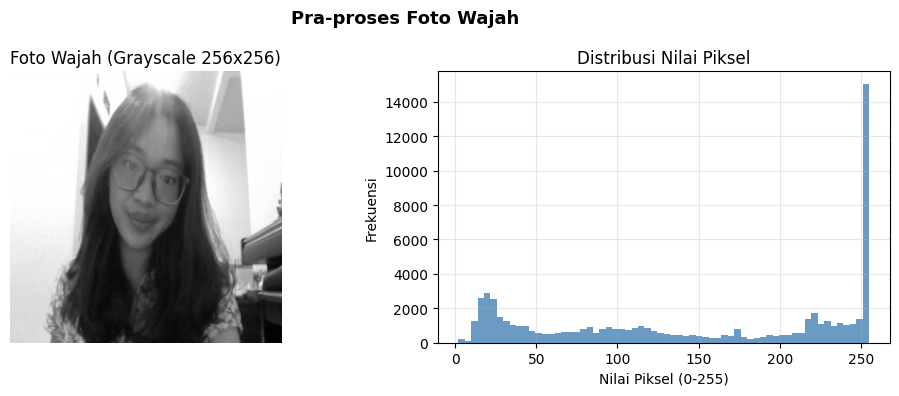

Tersimpan: 01_foto_asli.png


In [15]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

IMG_SIZE = 256
img_pil = Image.open(filename).convert('L').resize((IMG_SIZE, IMG_SIZE))
img_array = np.array(img_pil, dtype=np.uint8)

print(f'Nama file    : {filename}')
print(f'Ukuran citra : {img_array.shape}')
print(f'Nilai piksel : min={img_array.min()}, max={img_array.max()}, mean={img_array.mean():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Foto Wajah (Grayscale 256x256)')
axes[0].axis('off')

axes[1].hist(img_array.flatten(), bins=64, color='steelblue', alpha=0.8)
axes[1].set_title('Distribusi Nilai Piksel')
axes[1].set_xlabel('Nilai Piksel (0-255)')
axes[1].set_ylabel('Frekuensi')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Pra-proses Foto Wajah', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('01_foto_asli.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tersimpan: 01_foto_asli.png')

## Sel 3: Pembuatan Watermark Biner

Watermark adalah citra biner berukuran **64x64 piksel** (4096 bit) yang dibangkitkan secara acak dengan *seed* tetap sehingga dapat direproduksi. Nilai 0 dan 1 masing-masing merepresentasikan piksel hitam dan putih.

Ukuran watermark : (64, 64)
Jumlah bit       : 4096
Jumlah bit 0     : 2044 (49.9%)
Jumlah bit 1     : 2052 (50.1%)


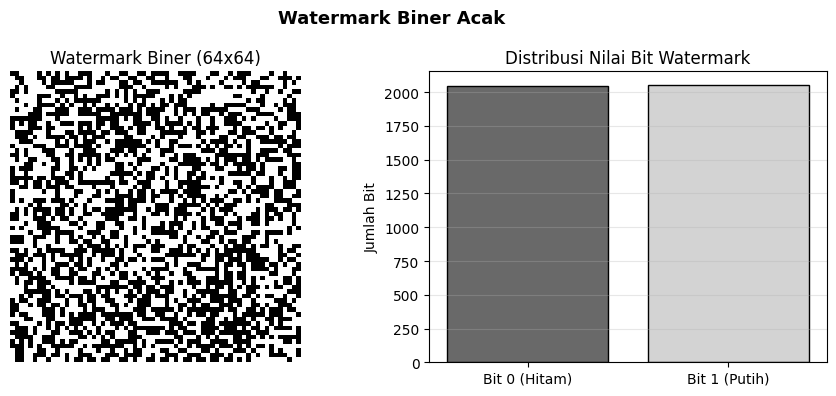

Tersimpan: 02_watermark_biner.png


In [27]:
np.random.seed(42)
WM_SIZE = 64
watermark = np.random.randint(0, 2, size=(WM_SIZE, WM_SIZE), dtype=np.uint8)

print(f'Ukuran watermark : {watermark.shape}')
print(f'Jumlah bit       : {watermark.size}')
print(f'Jumlah bit 0     : {np.sum(watermark == 0)} ({100*np.mean(watermark==0):.1f}%)')
print(f'Jumlah bit 1     : {np.sum(watermark == 1)} ({100*np.mean(watermark==1):.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(watermark, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Watermark Biner ({WM_SIZE}x{WM_SIZE})')
axes[0].axis('off')

axes[1].bar(['Bit 0 (Hitam)', 'Bit 1 (Putih)'],
            [np.sum(watermark == 0), np.sum(watermark == 1)],
            color=['dimgray', 'lightgray'], edgecolor='black')
axes[1].set_title('Distribusi Nilai Bit Watermark')
axes[1].set_ylabel('Jumlah Bit')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Watermark Biner Acak', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_watermark_biner.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tersimpan: 02_watermark_biner.png')

## Sel 4: Penyisipan Watermark dengan Metode LSB

**LSB (Least Significant Bit):** Bit paling tidak signifikan dari setiap piksel diganti dengan bit watermark. Perubahan nilai piksel hanya sebesar 0 atau 1, sehingga **tidak terlihat secara visual**.

Operasi penyisipan:
- `pixel_baru = (pixel_asli & 0b11111110) | bit_watermark`
- `& 0b11111110` : menghapus LSB (set ke 0)
- `| bit_watermark` : menyisipkan bit watermark di posisi LSB

Statistik penyisipan LSB:
  Nilai perbedaan max : 1
  MSE                 : 0.0320
  PSNR                : 63.08 dB


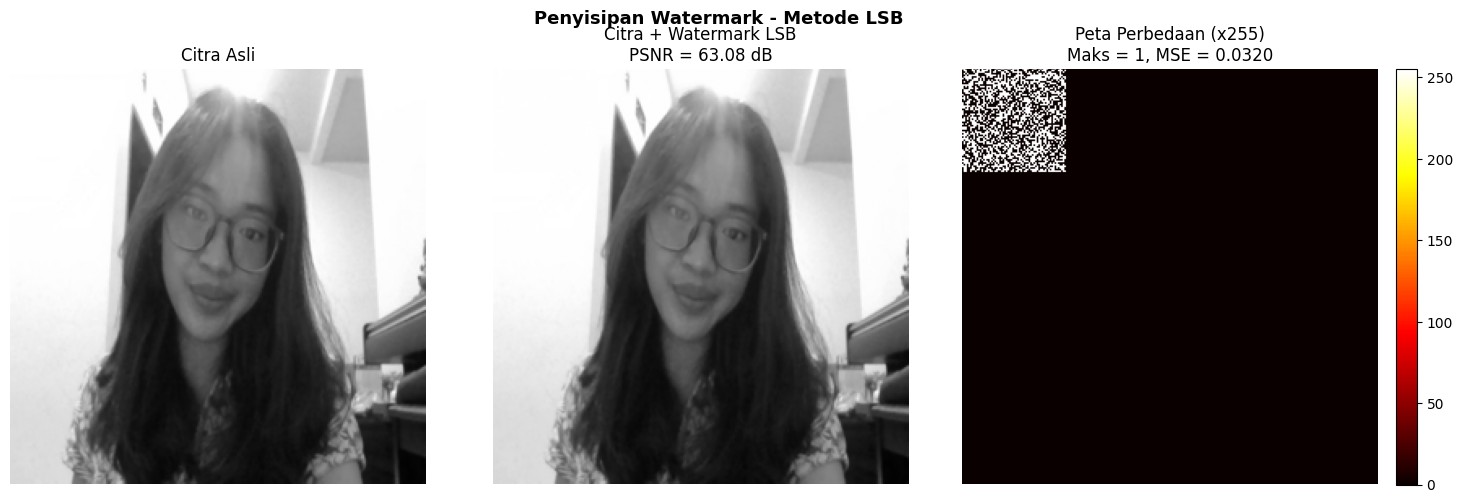

Tersimpan: 03_penyisipan_lsb.png


In [28]:
img_wm = img_array.copy()
img_wm[:WM_SIZE, :WM_SIZE] = (img_wm[:WM_SIZE, :WM_SIZE] & 0b11111110) | watermark

img_wm_pil = Image.fromarray(img_wm)
img_wm_pil.save('wajah_watermarked.png')

diff = np.abs(img_array.astype(np.int16) - img_wm.astype(np.int16))
mse = np.mean(diff ** 2)
psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

print('Statistik penyisipan LSB:')
print(f'  Nilai perbedaan max : {diff.max()}')
print(f'  MSE                 : {mse:.4f}')
print(f'  PSNR                : {psnr:.2f} dB')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Citra Asli')
axes[0].axis('off')

axes[1].imshow(img_wm, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Citra + Watermark LSB\nPSNR = {psnr:.2f} dB')
axes[1].axis('off')

axes[2].imshow(diff * 255, cmap='hot', vmin=0, vmax=255)
axes[2].set_title(f'Peta Perbedaan (x255)\nMaks = {diff.max()}, MSE = {mse:.4f}')
axes[2].axis('off')
plt.colorbar(axes[2].images[0], ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle('Penyisipan Watermark - Metode LSB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_penyisipan_lsb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tersimpan: 03_penyisipan_lsb.png')

## Sel 5: Pembuatan Matriks Kuantisasi JPEG

JPEG menggunakan **tabel kuantisasi standar luminance** (JPEG Annex K). Setiap elemen tabel menentukan seberapa kasar koefisien DCT dikuantisasi di frekuensi tersebut.

**Quality Factor (QF)** mengatur skala tabel kuantisasi:
- QF tinggi (100) = tabel kecil = kompresi ringan = kualitas tinggi
- QF rendah (10) = tabel besar = kompresi berat = banyak informasi hilang

Rumus skala (standar libjpeg):
- Jika QF < 50: `scale = 5000 / QF`
- Jika QF >= 50: `scale = 200 - 2*QF`
- `Q_scaled = floor((Q_base * scale + 50) / 100)`, minimal 1

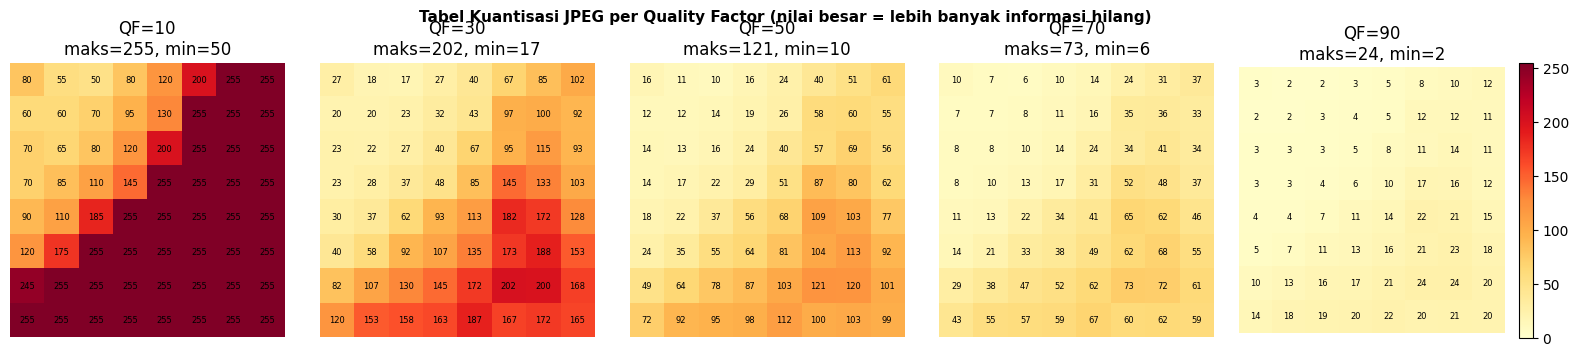

Tersimpan: 04_tabel_kuantisasi.png


In [29]:
Q50_BASE = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68,109,103, 77],
    [24, 35, 55, 64, 81,104,113, 92],
    [49, 64, 78, 87,103,121,120,101],
    [72, 92, 95, 98,112,100,103, 99]
], dtype=np.float64)

def make_qtable(qf):
    qf = max(1, min(99, qf))
    scale = 5000 / qf if qf < 50 else 200 - 2 * qf
    q = np.floor((Q50_BASE * scale + 50) / 100)
    return np.clip(q, 1, 255)

qf_demo = [10, 30, 50, 70, 90]

fig, axes = plt.subplots(1, len(qf_demo), figsize=(16, 3.5))
for ax, qf in zip(axes, qf_demo):
    q = make_qtable(qf)
    im = ax.imshow(q, cmap='YlOrRd', vmin=0, vmax=255)
    ax.set_title(f'QF={qf}\nmaks={int(q.max())}, min={int(q.min())}')
    ax.axis('off')
    for r in range(8):
        for c in range(8):
            ax.text(c, r, int(q[r, c]), ha='center', va='center',
                    fontsize=6, color='black')
plt.colorbar(im, ax=axes[-1], fraction=0.05)
plt.suptitle('Tabel Kuantisasi JPEG per Quality Factor (nilai besar = lebih banyak informasi hilang)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('04_tabel_kuantisasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tersimpan: 04_tabel_kuantisasi.png')

## Sel 6: Kompresi JPEG dengan Berbagai Quality Factor

Citra ber-watermark dikompres menggunakan PIL dengan QF yang divariasikan. Ukuran file dan PSNR terhadap citra ber-watermark (sebelum kompresi) dicatat untuk evaluasi.

Ukuran citra ber-watermark (PNG, lossless): 26.2 KB

   QF   Ukuran JPEG     Rasio     PSNR (dB)
----------------------------------------------
QF= 10        2.0 KB    12.8x        32.22
QF= 20        2.8 KB     9.4x        35.33
QF= 30        3.4 KB     7.7x        37.01
QF= 40        3.9 KB     6.6x        38.13
QF= 50        4.4 KB     5.9x        39.07
QF= 60        4.9 KB     5.3x        39.86
QF= 70        5.8 KB     4.5x        41.10
QF= 80        7.2 KB     3.6x        42.81
QF= 90       10.5 KB     2.5x        45.87
QF=100       27.5 KB     0.9x        59.13


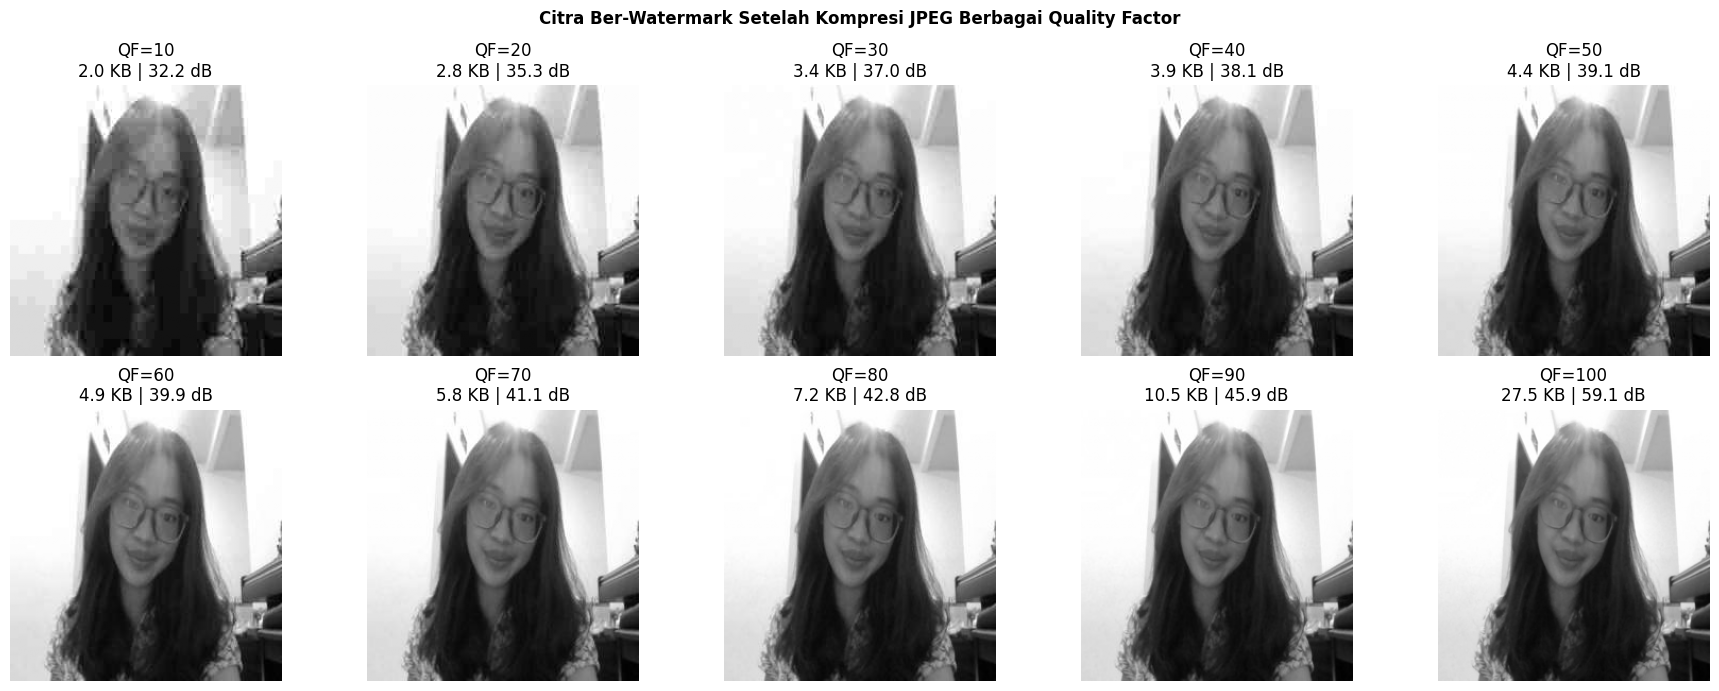

Tersimpan: 05_kompresi_jpeg.png


In [30]:
qf_list = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
compressed_images = {}
file_sizes = {}
psnr_values = {}

def compute_psnr(ref, cmp):
    mse = np.mean((ref.astype(np.float64) - cmp.astype(np.float64)) ** 2)
    return 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

original_size = os.path.getsize('wajah_watermarked.png')

print(f'Ukuran citra ber-watermark (PNG, lossless): {original_size/1024:.1f} KB')
print()
print(f'{"QF":>5}  {"Ukuran JPEG":>12}  {"Rasio":>8}  {"PSNR (dB)":>12}')
print('-' * 46)

for qf in qf_list:
    buf = io.BytesIO()
    img_wm_pil.save(buf, format='JPEG', quality=qf)
    size = buf.tell()
    buf.seek(0)
    img_c = np.array(Image.open(buf).convert('L'))
    compressed_images[qf] = img_c
    file_sizes[qf] = size
    psnr_val = compute_psnr(img_wm, img_c)
    psnr_values[qf] = psnr_val
    ratio = original_size / size
    path = f'wajah_qf{qf}.jpg'
    img_wm_pil.save(path, 'JPEG', quality=qf)
    print(f'QF={qf:>3}  {size/1024:>9.1f} KB  {ratio:>6.1f}x    {psnr_val:>9.2f}')

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, qf in zip(axes.flatten(), qf_list):
    ax.imshow(compressed_images[qf], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'QF={qf}\n{file_sizes[qf]/1024:.1f} KB | {psnr_values[qf]:.1f} dB')
    ax.axis('off')

plt.suptitle('Citra Ber-Watermark Setelah Kompresi JPEG Berbagai Quality Factor',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('05_kompresi_jpeg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tersimpan: 05_kompresi_jpeg.png')

## Sel 7: Grafik Ukuran File dan PSNR vs Quality Factor

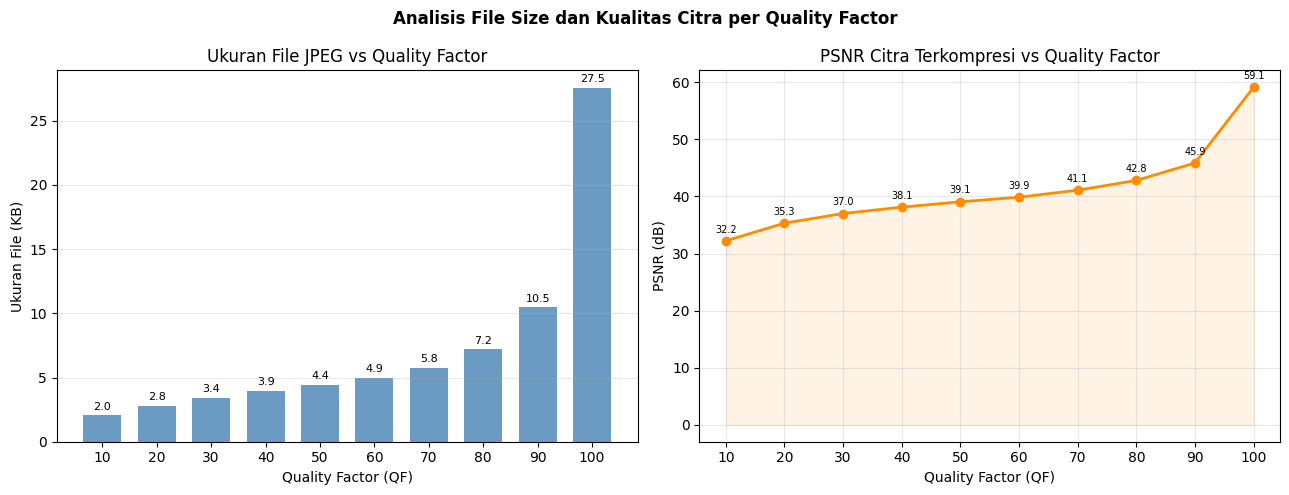

Tersimpan: 06_grafik_ukuran_psnr.png


In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sizes_kb = [file_sizes[qf] / 1024 for qf in qf_list]
bars = ax1.bar(qf_list, sizes_kb, color='steelblue', alpha=0.8, width=7)
for bar, size in zip(bars, sizes_kb):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{size:.1f}', ha='center', va='bottom', fontsize=8)
ax1.set_title('Ukuran File JPEG vs Quality Factor')
ax1.set_xlabel('Quality Factor (QF)')
ax1.set_ylabel('Ukuran File (KB)')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(qf_list)

psnr_vals = [psnr_values[qf] for qf in qf_list]
ax2.plot(qf_list, psnr_vals, 'o-', color='darkorange', linewidth=2, markersize=6)
ax2.fill_between(qf_list, psnr_vals, alpha=0.1, color='darkorange')
ax2.set_title('PSNR Citra Terkompresi vs Quality Factor')
ax2.set_xlabel('Quality Factor (QF)')
ax2.set_ylabel('PSNR (dB)')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(qf_list)
for qf, pv in zip(qf_list, psnr_vals):
    ax2.annotate(f'{pv:.1f}', xy=(qf, pv), xytext=(0, 6),
                 textcoords='offset points', ha='center', fontsize=7)

plt.suptitle('Analisis File Size dan Kualitas Citra per Quality Factor',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('06_grafik_ukuran_psnr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tersimpan: 06_grafik_ukuran_psnr.png')

## Sel 8: Ekstraksi Watermark dan Perhitungan BER

**Ekstraksi LSB:** Baca bit LSB dari blok piksel yang sama tempat watermark disisipkan.

**BER (Bit Error Rate):** Persentase bit watermark yang salah setelah ekstraksi.
- BER = 0%: watermark terekstrak sempurna
- BER ~ 50%: watermark tidak dapat dikenali (acak)

Ambang batas yang digunakan: **BER < 10%** = watermark masih dapat dikenali.

In [32]:
def extract_watermark(img_arr, wm_shape=(64, 64)):
    h, w = wm_shape
    region = img_arr[:h, :w]
    return (region & 1).astype(np.uint8)

def ber(wm_orig, wm_ext):
    return np.sum(wm_orig != wm_ext) / wm_orig.size

extracted = {}
ber_values = {}

print(f'{"QF":>5}  {"BER":>8}  {"BER (%)":>9}  {"Status"}')
print('-' * 48)

for qf in qf_list:
    wm_ext = extract_watermark(compressed[qf])
    extracted[qf] = wm_ext
    b = ber(watermark, wm_ext)
    ber_values[qf] = b
    status = 'Dapat diekstrak' if b < 0.1 else 'Tidak dapat diekstrak'
    print(f'QF={qf:>3}  {b:.4f}    {b*100:>6.2f}%    {status}')

   QF       BER    BER (%)  Status
------------------------------------------------
QF= 10  0.4990     49.90%    Tidak dapat diekstrak
QF= 20  0.4990     49.90%    Tidak dapat diekstrak
QF= 30  0.4990     49.90%    Tidak dapat diekstrak
QF= 40  0.4990     49.90%    Tidak dapat diekstrak
QF= 50  0.5010     50.10%    Tidak dapat diekstrak
QF= 60  0.4990     49.90%    Tidak dapat diekstrak
QF= 70  0.5010     50.10%    Tidak dapat diekstrak
QF= 80  0.4863     48.63%    Tidak dapat diekstrak
QF= 90  0.4443     44.43%    Tidak dapat diekstrak
QF=100  0.0632      6.32%    Dapat diekstrak


## Sel 9: Visualisasi Watermark Hasil Ekstraksi per Quality Factor

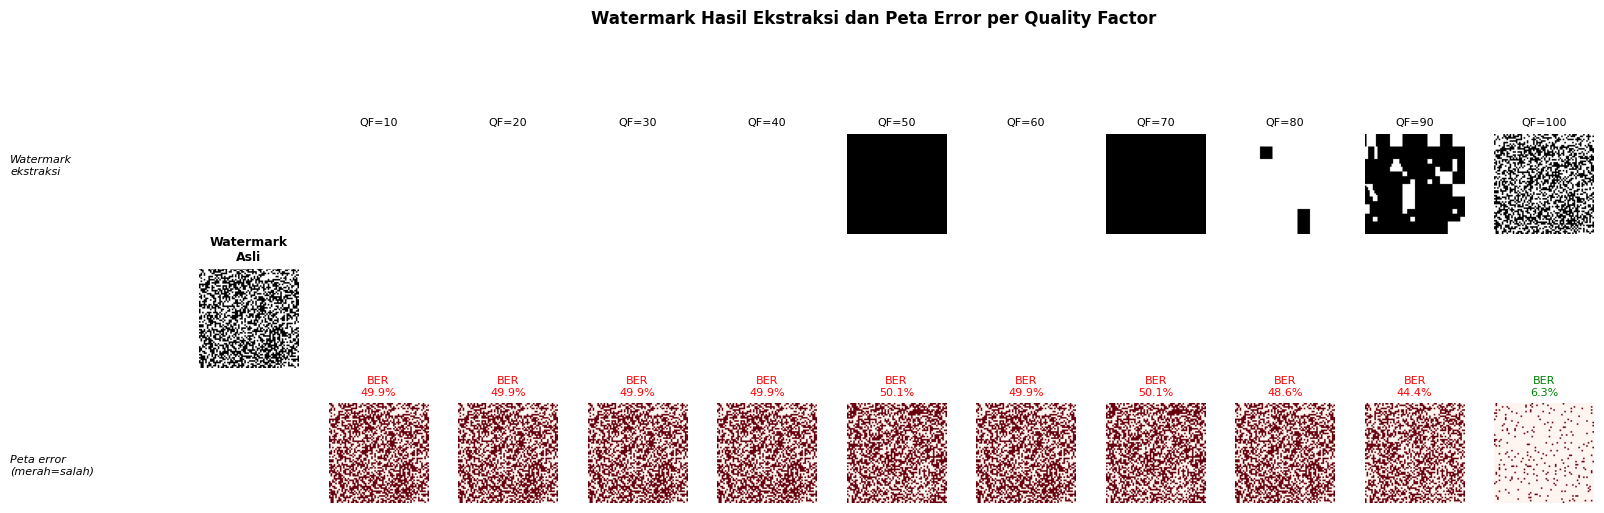

Tersimpan: 07_hasil_ekstraksi.png


In [33]:
fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(2, 11, figure=fig, wspace=0.3, hspace=0.4)

ax_orig = fig.add_subplot(gs[:, 0])
ax_orig.imshow(watermark, cmap='gray', vmin=0, vmax=1)
ax_orig.set_title('Watermark\nAsli', fontsize=9, fontweight='bold')
ax_orig.axis('off')

for col, qf in enumerate(qf_list):
    b = ber_values[qf]
    ax_top = fig.add_subplot(gs[0, col + 1])
    ax_top.imshow(extracted[qf], cmap='gray', vmin=0, vmax=1)
    color = 'green' if b < 0.1 else 'red'
    ax_top.set_title(f'QF={qf}', fontsize=8)
    ax_top.axis('off')

    ax_bot = fig.add_subplot(gs[1, col + 1])
    err_map = (extracted[qf] != watermark).astype(np.uint8)
    ax_bot.imshow(err_map, cmap='Reds', vmin=0, vmax=1)
    ax_bot.set_title(f'BER\n{b*100:.1f}%', fontsize=8, color=color)
    ax_bot.axis('off')

fig.text(0.02, 0.75, 'Watermark\nekstraksi', va='center', fontsize=8, style='italic')
fig.text(0.02, 0.25, 'Peta error\n(merah=salah)', va='center', fontsize=8, style='italic')

plt.suptitle('Watermark Hasil Ekstraksi dan Peta Error per Quality Factor',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig('07_hasil_ekstraksi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tersimpan: 07_hasil_ekstraksi.png')

## Sel 10: Grafik BER vs Quality Factor dan Penentuan Threshold

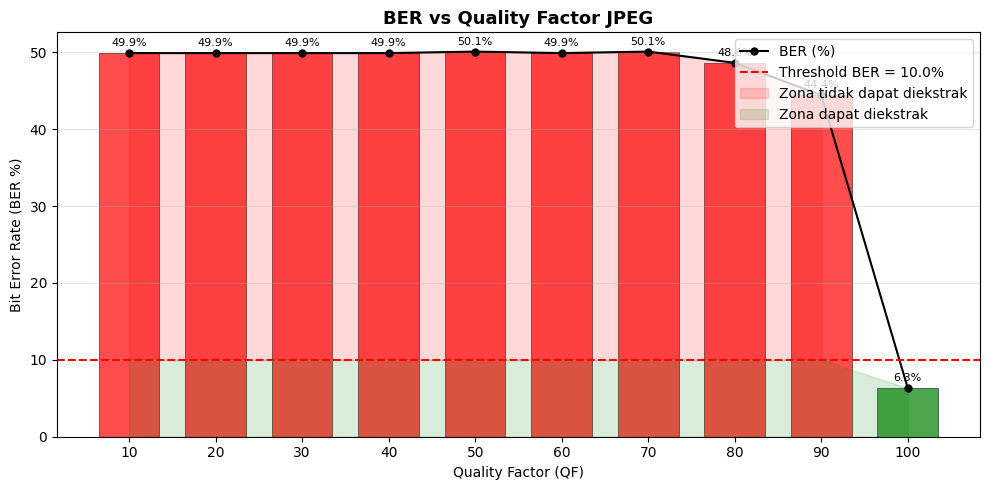

Tersimpan: 08_grafik_ber.png

Kesimpulan:
  QF= 10  BER= 49.90%  -> TIDAK DAPAT diekstrak (BER >= 10%)
  QF= 20  BER= 49.90%  -> TIDAK DAPAT diekstrak (BER >= 10%)
  QF= 30  BER= 49.90%  -> TIDAK DAPAT diekstrak (BER >= 10%)
  QF= 40  BER= 49.90%  -> TIDAK DAPAT diekstrak (BER >= 10%)
  QF= 50  BER= 50.10%  -> TIDAK DAPAT diekstrak (BER >= 10%)
  QF= 60  BER= 49.90%  -> TIDAK DAPAT diekstrak (BER >= 10%)
  QF= 70  BER= 50.10%  -> TIDAK DAPAT diekstrak (BER >= 10%)
  QF= 80  BER= 48.63%  -> TIDAK DAPAT diekstrak (BER >= 10%)
  QF= 90  BER= 44.43%  -> TIDAK DAPAT diekstrak (BER >= 10%)
  QF=100  BER=  6.32%  -> DAPAT diekstrak    (BER < 10%)

Watermark mulai tidak dapat diekstrak pada QF = 10


In [23]:
ber_pct = [ber_values[qf] * 100 for qf in qf_list]
THRESHOLD = 10.0

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['green' if b < THRESHOLD else 'red' for b in ber_pct]
ax.bar(qf_list, ber_pct, color=colors, alpha=0.7, width=7, edgecolor='black', linewidth=0.5)
ax.plot(qf_list, ber_pct, 'ko-', linewidth=1.5, markersize=5, label='BER (%)')

ax.axhline(y=THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold BER = {THRESHOLD}%')
ax.fill_between(qf_list, ber_pct, THRESHOLD,
                where=[b > THRESHOLD for b in ber_pct],
                alpha=0.15, color='red', label='Zona tidak dapat diekstrak')
ax.fill_between(qf_list, [min(b, THRESHOLD) for b in ber_pct], 0,
                alpha=0.15, color='green', label='Zona dapat diekstrak')

for qf, b in zip(qf_list, ber_pct):
    ax.annotate(f'{b:.1f}%', xy=(qf, b), xytext=(0, 5),
                textcoords='offset points', ha='center', fontsize=8)

ax.set_title('BER vs Quality Factor JPEG', fontsize=13, fontweight='bold')
ax.set_xlabel('Quality Factor (QF)')
ax.set_ylabel('Bit Error Rate (BER %)')
ax.set_xticks(qf_list)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('08_grafik_ber.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tersimpan: 08_grafik_ber.png')

print()
print('Kesimpulan:')
threshold_qf = None
for qf in sorted(qf_list):
    b = ber_values[qf] * 100
    status = 'DAPAT diekstrak    (BER < 10%)' if b < THRESHOLD else 'TIDAK DAPAT diekstrak (BER >= 10%)'
    print(f'  QF={qf:>3}  BER={b:>6.2f}%  -> {status}')
    if threshold_qf is None and b >= THRESHOLD:
        threshold_qf = qf

print()
if threshold_qf:
    print(f'Watermark mulai tidak dapat diekstrak pada QF = {threshold_qf}')
else:
    print('Watermark dapat diekstrak di semua QF yang diuji.')

## Sel 11: Ringkasan Hasil dalam Bentuk Tabel

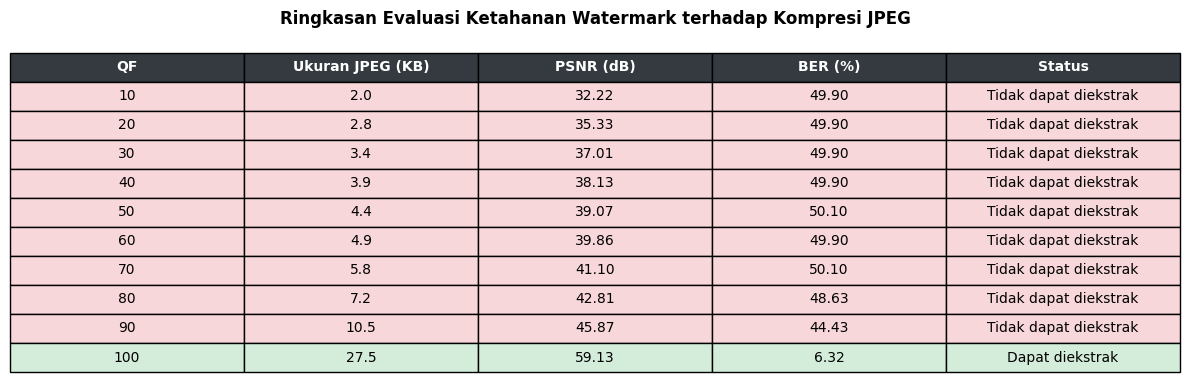

Tersimpan: 09_tabel_hasil.png


In [24]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

col_labels = ['QF', 'Ukuran JPEG (KB)', 'PSNR (dB)', 'BER (%)', 'Status']
row_data = []
cell_colors = []

for qf in qf_list:
    b = ber_values[qf] * 100
    status = 'Dapat diekstrak' if b < 10 else 'Tidak dapat diekstrak'
    row_data.append([
        str(qf),
        f"{file_sizes[qf]/1024:.1f}",
        f"{psnr_values[qf]:.2f}",
        f"{b:.2f}",
        status
    ])
    row_color = ['#d4edda' if b < 10 else '#f8d7da'] * 5
    cell_colors.append(row_color)

table = ax.table(
    cellText=row_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#343a40')
    table[0, j].set_text_props(color='white', fontweight='bold')

plt.title('Ringkasan Evaluasi Ketahanan Watermark terhadap Kompresi JPEG',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('09_tabel_hasil.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tersimpan: 09_tabel_hasil.png')

## Sel 12: Download Semua Output

Sel ini mengunduh semua gambar hasil yang telah tersimpan selama eksekusi notebook.

In [26]:
output_files = [
    '01_foto_asli.png',
    '02_watermark_biner.png',
    '03_penyisipan_lsb.png',
    '04_tabel_kuantisasi.png',
    '05_kompresi_jpeg.png',
    '06_grafik_ukuran_psnr.png',
    '07_hasil_ekstraksi.png',
    '08_grafik_ber.png',
    '09_tabel_hasil.png',
]

print('Mengunduh file output...')
print()
for f in output_files:
    if os.path.exists(f):
        files.download(f)
        size_kb = os.path.getsize(f) / 1024
        print(f'  {f} ({size_kb:.1f} KB)')
    else:
        print(f'  File tidak ditemukan: {f}')

print()
print(f'Total: {len(output_files)} file diunduh.')

Mengunduh file output...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  01_foto_asli.png (137.1 KB)


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  08_grafik_ber.png (73.5 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  09_tabel_hasil.png (108.0 KB)

Total: 9 file diunduh.
